In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd



In [3]:
#class imbalance>> when one class has higher percentage of samples
#solutions:
#1. undersampling
#2. oversampling
#3. synthetic data generation

In [4]:
np.random.seed(1) #for reproducibility of results

In [5]:
no_samples=1000
class_0_ratio=0.9
no_class_0=int(no_samples*class_0_ratio)
no_class_1=no_samples-no_class_0

In [6]:
no_class_0, no_class_1

(900, 100)

In [7]:
class_0={
    'feature1':np.random.normal(loc=0, scale=1, size=no_class_0),
    'feature2':np.random.normal(loc=0, scale=1, size=no_class_0),
    'target':[0]*no_class_0
}



In [8]:
class_0

{'feature1': array([ 1.62434536e+00, -6.11756414e-01, -5.28171752e-01, -1.07296862e+00,
         8.65407629e-01, -2.30153870e+00,  1.74481176e+00, -7.61206901e-01,
         3.19039096e-01, -2.49370375e-01,  1.46210794e+00, -2.06014071e+00,
        -3.22417204e-01, -3.84054355e-01,  1.13376944e+00, -1.09989127e+00,
        -1.72428208e-01, -8.77858418e-01,  4.22137467e-02,  5.82815214e-01,
        -1.10061918e+00,  1.14472371e+00,  9.01590721e-01,  5.02494339e-01,
         9.00855949e-01, -6.83727859e-01, -1.22890226e-01, -9.35769434e-01,
        -2.67888080e-01,  5.30355467e-01, -6.91660752e-01, -3.96753527e-01,
        -6.87172700e-01, -8.45205641e-01, -6.71246131e-01, -1.26645989e-02,
        -1.11731035e+00,  2.34415698e-01,  1.65980218e+00,  7.42044161e-01,
        -1.91835552e-01, -8.87628964e-01, -7.47158294e-01,  1.69245460e+00,
         5.08077548e-02, -6.36995647e-01,  1.90915485e-01,  2.10025514e+00,
         1.20158952e-01,  6.17203110e-01,  3.00170320e-01, -3.52249846e-01,


In [9]:
class_0=pd.DataFrame(class_0)

In [10]:
class_0

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [11]:
class_1=pd.DataFrame({
    'feature1':np.random.normal(loc=3, scale=1, size=no_class_1),
    'feature2':np.random.normal(loc=3, scale=1, size=no_class_1),
    'target':[1]*no_class_1
})

In [12]:
class_1

,feature1,feature2,target
0,1.692029,3.933630,1
1,4.472396,1.236225,1
2,3.074876,2.589783,1
3,1.213065,2.546333,1
4,3.165211,2.410570,1
...,...,...,...
95,3.213026,3.188583,1
96,2.195458,3.560918,1
97,2.353418,2.078341,1
98,4.138173,3.647375,1


In [15]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)
df

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
995,3.213026,3.188583,1
996,2.195458,3.560918,1
997,2.353418,2.078341,1
998,4.138173,3.647375,1


In [16]:
df.target.value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [ ]:
#upsampling
df_minority=df[df.target==1]
df_majority=df[df.target==0]

In [18]:
df_majority.shape, df_minority.shape

((900, 3), (100, 3))

In [19]:
#replace=True>> to allow sampling of same data points multiple times
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=1)

In [20]:
df_minority_upsampled

,feature1,feature2,target
937,2.253776,1.681477,1
912,2.448320,2.898619,1
972,2.541698,2.700847,1
909,1.724886,1.748043,1
975,2.427974,4.613562,1
...,...,...,...
936,4.093307,2.373543,1
998,4.138173,3.647375,1
901,4.472396,1.236225,1
932,1.965537,4.084419,1


In [22]:
df_upsampled=pd.concat([df_majority, df_minority_upsampled]) #type:ignore

In [23]:
df_upsampled.target.value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [24]:
#SMOTE>>synthetic minority oversampling technique
from sklearn.datasets import make_classification
X,Y=make_classification(n_samples=1000, n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0.9])

In [25]:
X

array([[-1.07876139,  0.6322917 ],
       [-1.62310799, -0.05386502],
       [-0.92187944,  1.34630462],
       ...,
       [-2.22214902, -1.74577853],
       [-0.9482506 ,  1.25173138],
       [-1.19836117,  1.37319785]], shape=(1000, 2))

In [26]:
Y


array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [27]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(Y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df

,f1,f2,target
0,-1.078761,0.632292,0
1,-1.623108,-0.053865,0
2,-0.921879,1.346305,0
3,-2.014224,0.242973,0
4,0.707407,0.382432,1
...,...,...,...
995,-1.617138,0.720443,0
996,-0.674183,1.593318,0
997,-2.222149,-1.745779,1
998,-0.948251,1.251731,0


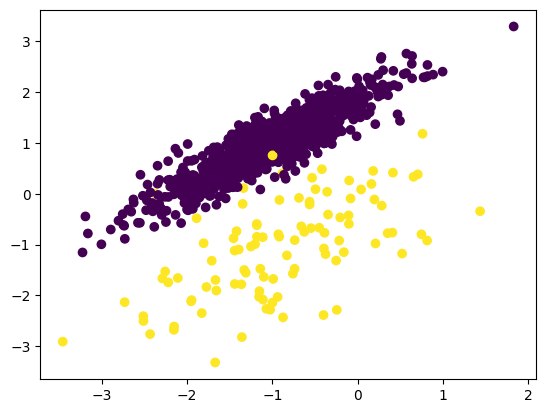

In [28]:
import matplotlib.pyplot as plt
plt.scatter(final_df.f1, final_df.f2, c=final_df.target)

In [29]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
X_smote, Y_smote=smote.fit_resample(final_df[['f1','f2']], final_df['target']) #type:ignore

In [32]:
X_smote.shape, Y_smote.shape

((1794, 2), (1794,))

In [33]:
df1=pd.DataFrame(X, columns=['f1','f2'])
df2=pd.DataFrame(Y, columns=['target'])
smote_df=pd.concat([df1, df2], axis=1)

In [34]:
smote_df

,f1,f2,target
0,-1.078761,0.632292,0
1,-1.623108,-0.053865,0
2,-0.921879,1.346305,0
3,-2.014224,0.242973,0
4,0.707407,0.382432,1
...,...,...,...
995,-1.617138,0.720443,0
996,-0.674183,1.593318,0
997,-2.222149,-1.745779,1
998,-0.948251,1.251731,0


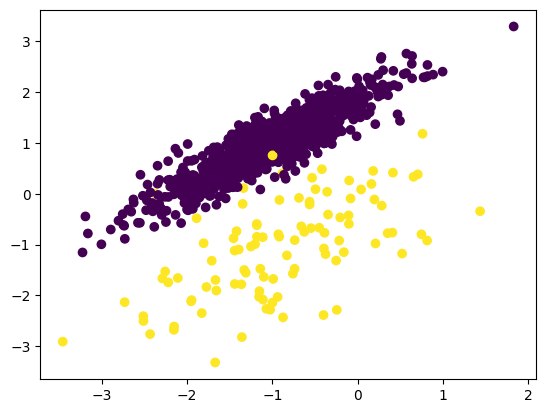

In [35]:
plt.scatter(smote_df.f1, smote_df.f2, c=smote_df.target)